Already written all the different notebooks - just need to combine in order to just store the relevant information. 


In [ ]:
import optuna
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import lightgbm as lgb

from datetime import datetime
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error


from mtl_function import custom_multi_loss


In [ ]:
SEED = 15

# Set dataset (model) [options: full_dataset, maccs, mordred, ecfp, ecfp_mordred, ecfp_maccs, mordred_maccs]
ds = 'full_dataset'
full_dataset_path = '../datasets/b3db_drug_like_labelled.csv'

# Set output file paths
output_optuna_db = f'../model_results/{ds}/lgb_b3db_drug_like_labelled_{SEED}_{ds}_final' # mordred_maccs_
optuna_study_name_root = f'lgb_b3db_drug_like_labelled_{SEED}_{ds}_final' # mordred_maccs_
training_output_file_path = f'../model_results/{ds}/training_output_values_{SEED}_{ds}_final.csv'
shap_output_file_path = f'../model_results/{ds}/training_shap_output_values_{SEED}_{ds}_final.csv'
model_root_path = f'../model_results/{ds}/trained_lgb_b3db_drug_like_labelled_{SEED}_{ds}_final'


In [ ]:
# Import Dataset
full_df = pd.read_csv(full_dataset_path)

smiles = full_df.loc[:, 'SMILES']
bbb_class = full_df.loc[:, 'Class']
logbb = full_df.loc[:, 'logBB']

starting_col = list(full_df.columns).index('Class') + 1
X_full = full_df.iloc[:, starting_col:]

bbb_class = np.array(bbb_class)
logbb = np.array(logbb)


if ds == 'full_dataset': 
    X_full = X_full
    col_names = list(full_df.columns)[starting_col:]
elif ds == 'ecfp': 
    X_full = X_full.iloc[:, :2048]
    col_names = list(full_df.columns)[starting_col:][:2048]
elif ds == 'maccs': 
    X_full = X_full.iloc[:, -167:]
    col_names = list(full_df.columns)[starting_col:][-167:]
elif ds == 'mordred': 
    X_full = X_full.iloc[:, 2048:-167]
    col_names = list(full_df.columns)[starting_col:][2048:-167]
elif ds == 'ecfp_mordred': 
    X_full = X_full.iloc[:, :-167]
    col_names = list(full_df.columns)[starting_col:][:-167]
elif ds == 'mordred_maccs': 
    X_full = X_full.iloc[:, 2048:]
    col_names = list(full_df.columns)[starting_col:][2048:]
elif ds == 'ecfp_maccs': 
    X_full = X_full.drop(X_full.columns[2048:-167], axis=1)
    col_names = list(full_df.columns)[starting_col:][:2048] + list(full_df.columns)[starting_col:][-167:]
else: 
    print('Invalid dataset specified, proceeding with the full dataset')


X_full = X_full.values
X_to_drop = pd.DataFrame(data=X_full, columns=col_names)
X_full_no_nan = X_to_drop.dropna(axis=1)
X_full_no_nan = X_full_no_nan.loc[:, X_full_no_nan.std() != 0]

X_all = X_full_no_nan.values

In [ ]:
# Training and cross validation: 

n_outer = 5

outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=SEED)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


full_set_scores = [0] * n_outer
best_params_all = []
balanced_acc_outer, prec_outer, recall_outer, rocauc_outer, prauc_outer, kappa_outer, mcc_outer, f1_outer  = [], [], [], [], [], [], [], []
mae_outer, mse_outer, mde_outer, r2_outer, pearson_outer = [],[],[],[],[]
all_vals = []
shap_values_all = []
pearson_sim_all = []
all_max_sim = []
abs_error_all = []
all_preds = []
all_trues_r = []
all_trues_c = []

shap_means_all_outers=[]

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print('Timestamp included in optuna db name: ', timestamp)

count_outer = 0
for train_idx, test_idx in outer_cv.split(X_all, bbb_class):
    count_outer +=1
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train_c, y_test_c = bbb_class[train_idx], bbb_class[test_idx]
    y_train_r, y_test_r = logbb[train_idx], logbb[test_idx]
    smiles_train, smiles_test = smiles[train_idx], smiles[test_idx]

    def objective(trial):
        
        mse = []
        count_inner = 1
        for inner_train_idx, val_idx in inner_cv.split(X_train, y_train_c):
            X_inner_train, X_val = X_train[inner_train_idx], X_train[val_idx]
            y_inner_train_c, y_val_c = y_train_c[inner_train_idx], y_train_c[val_idx]
            y_inner_train_r, y_val_r = y_train_r[inner_train_idx], y_train_r[val_idx]

            train_data = lgb.Dataset(X_inner_train, label=y_inner_train_r)
            val_data = lgb.Dataset(X_val, label=y_val_r)

            params = {
            "objective": custom_multi_loss(y_inner_train_c, y_inner_train_r, alpha=1, beta=2, 
                                           margin_buffer=trial.suggest_float("margin_buffer", 0.15, 0.35, step=0.02)),  # Custom loss function
            "metric": "None",               
            "boosting_type": "gbdt",
            "verbosity": -1,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "num_leaves": trial.suggest_int("num_leaves", 20, 150),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            'seed': (SEED + count_outer)* count_inner,
            'feature_fraction_seed': (SEED + count_outer)* count_inner,
            'bagging_seed': (SEED + count_outer)* count_inner,
            'drop_seed': (SEED + count_outer)* count_inner,
            'data_random_seed': (SEED + count_outer)* count_inner,
            'extra_seed': (SEED + count_outer)* count_inner,
            # 'feature_fraction': 1.0,  
            # 'bagging_fraction': 1.0,  
            # 'bagging_freq': 0,        
            'force_col_wise': True,   
            'num_threads': 1,  
        }
            model = lgb.train(
                params,
                train_data,
                num_boost_round=1000,
                valid_sets=[val_data],
            )

            y_val_pred = model.predict(X_val, num_iteration=model.best_iteration)
            mse.append(mean_squared_error(y_val_r[~np.isnan(y_val_r)], y_val_pred[~np.isnan(y_val_r)]))
            
            count_inner += 1

        return np.mean(mse) 

    # Run Optuna for inner loop
    study = optuna.create_study(direction="minimize", 
                                storage=f'sqlite:///{output_optuna_db}_{timestamp}.db', 
                                study_name=f'{optuna_study_name_root}_outerfold_{count_outer}', 
                                sampler=optuna.samplers.TPESampler(seed=SEED*count_outer), 
                                pruner=optuna.pruners.BasePruner, 
                                )
    
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    # Train final model on full inner train set using best params
    best_params = study.best_trial.params
    best_params.update({
        "objective": custom_multi_loss(y_train_c, y_train_r, margin_buffer=best_params['margin_buffer'],alpha=1.0, beta=2.5, k=10), 
        "metric": "None",
        "verbosity": -1,
        "boosting_type": "gbdt"
    })

    best_params_all.append(best_params)

    train_data = lgb.Dataset(X_train, label=y_train_r)
    test_data = lgb.Dataset(X_test, label=y_test_r)

    final_model = lgb.train(
        best_params,
        train_data,
        num_boost_round=1000,
        valid_sets=[test_data],
    )

    
    y_test_pred = final_model.predict(X_test, num_iteration=final_model.best_iteration)
    all_preds.extend(y_test_pred)
    all_trues_r.extend(y_test_r)
    all_trues_c.extend(y_test_c)


    # Determine predictions that include the training dataset for that outerfold: 
    full_set_scores[count_outer-1] = final_model.predict(X_all, num_iteration=final_model.best_iteration)

    # Get SHAP values
    explainer = shap.Explainer(final_model)
    shap_vals = explainer(X_test)

    # Calculate mean SHAP values for each fold
    shap_means_all_outers.append(np.mean(shap_vals.values, axis=0))

    # Save the best model from each outerfold: 
    final_model.save_model(f'{model_root_path}_{count_outer}.txt')


shap_df = pd.DataFrame(shap_means_all_outers, columns=list(X_full_no_nan.columns))
shap_df.to_csv(f"{shap_output_file_path}")

features_to_output = [logbb, bbb_class, all_preds, all_trues_r, all_trues_c] +  [full_set_scores[i] for i in range(n_outer)]
col_names_to_output = ['logbb','bbb_class', 'all_preds', 'all_trues_r', 'all_trues_c'] + [f'full_set_scores_fold_{i}' for i in range(n_outer)]

output_vals = pd.DataFrame(np.transpose(features_to_output), columns= col_names_to_output)
output_vals.to_csv(training_output_file_path)

Timestamp included in optuna db name:  20251130_151759


[I 2025-11-30 15:18:00,319] A new study created in RDB with name: lgb_b3db_drug_like_labelled_85_mordred_final_outerfold_1
Best trial: 0. Best value: 0.560398:   3%|▎         | 1/30 [01:37<47:21, 97.98s/it]

[I 2025-11-30 15:19:38,293] Trial 0 finished with value: 0.5603978286610107 and parameters: {'margin_buffer': 0.27, 'learning_rate': 0.157596389907168, 'num_leaves': 59, 'max_depth': 9, 'min_child_samples': 17, 'subsample': 0.7615630391750171, 'colsample_bytree': 0.6866248710496383}. Best is trial 0 with value: 0.5603978286610107.


Best trial: 0. Best value: 0.560398:   7%|▋         | 2/30 [04:04<59:08, 126.73s/it]

[I 2025-11-30 15:22:05,160] Trial 1 finished with value: 0.5805304863802757 and parameters: {'margin_buffer': 0.22999999999999998, 'learning_rate': 0.22306114440875616, 'num_leaves': 104, 'max_depth': 12, 'min_child_samples': 15, 'subsample': 0.7027763768535312, 'colsample_bytree': 0.941840370200383}. Best is trial 0 with value: 0.5603978286610107.


...

[I 2025-11-30 18:37:44,342] Trial 27 finished with value: 0.5379503470223953 and parameters: {'margin_buffer': 0.31, 'learning_rate': 0.1354783716719913, 'num_leaves': 60, 'max_depth': 6, 'min_child_samples': 18, 'subsample': 0.8670655953720308, 'colsample_bytree': 0.6651614238045125}. Best is trial 11 with value: 0.27212995670862516.


Best trial: 11. Best value: 0.27213:  97%|█████████▋| 29/30 [28:41<00:58, 58.61s/it]

[I 2025-11-30 18:38:51,740] Trial 28 finished with value: 0.48573737749514356 and parameters: {'margin_buffer': 0.32999999999999996, 'learning_rate': 0.07457926002250026, 'num_leaves': 28, 'max_depth': 11, 'min_child_samples': 31, 'subsample': 0.7932673472598315, 'colsample_bytree': 0.7222866665472332}. Best is trial 11 with value: 0.27212995670862516.


Best trial: 11. Best value: 0.27213: 100%|██████████| 30/30 [29:18<00:00, 58.63s/it]


[I 2025-11-30 18:39:28,781] Trial 29 finished with value: 0.44092223129277075 and parameters: {'margin_buffer': 0.31, 'learning_rate': 0.09222051604927932, 'num_leaves': 134, 'max_depth': 5, 'min_child_samples': 34, 'subsample': 0.6873916110179824, 'colsample_bytree': 0.7765543891376911}. Best is trial 11 with value: 0.27212995670862516.


[01:16:19] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[01:16:24] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[01:16:29] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[01:16:35] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry
[01:16:40] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry


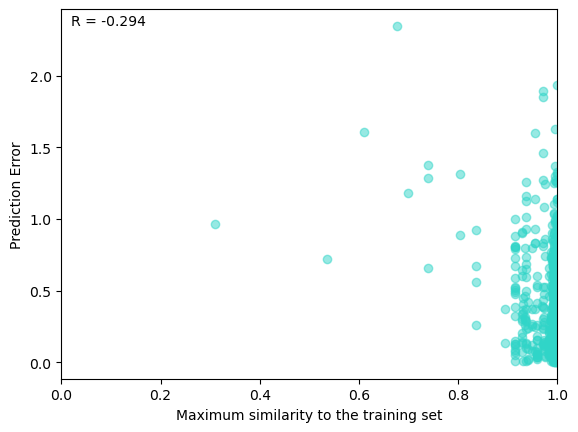

In [18]:
# prediction error against the similarity between training dataset 

from feature_selection import similarity_train_test
from scipy.stats import pearsonr

colors = ["#F35965", "#6BF178", "#3EA7FF", "#8633A8", "#30D5C8", "#DC8DC4"]

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
outer_fold = 1
count=-1

all_max_sim = []
all_pred_error = []

count_outer = 0
for train_idx, test_idx in outer_cv.split(X_all, bbb_class):
    count_outer +=1
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train_c, y_test_c = bbb_class[train_idx], bbb_class[test_idx]
    # y_train_r, y_test_r = np.array([np.nan]*len(bbb_class))[train_idx], np.array([np.nan]*len(bbb_class))[test_idx], 
    y_train_r, y_test_r = logbb[train_idx], logbb[test_idx]
    smiles_train, smiles_test = smiles[train_idx], smiles[test_idx]


    model = lgb.Booster(model_file=f'../model_results/full_dataset/trained_lgb_b3db_drug_like_labelled_15_full_dataset_final_{count_outer}.txt')
    predictions = model.predict(X_test)

    max_sim = similarity_train_test(smiles_train, smiles_test[~np.isnan(y_test_r)])
    all_max_sim.extend(max_sim)

    prediction_error = np.abs((np.array(predictions[~np.isnan(y_test_r)])-np.array(y_test_r[~np.isnan(y_test_r)])))
    all_pred_error.extend(prediction_error)


all_pred_error = np.array(all_pred_error, dtype=float)
all_max_sim = np.array(all_max_sim, dtype=float)

r2_errors = pearsonr(all_max_sim[~np.isnan(all_pred_error)], all_pred_error[~np.isnan(all_pred_error)]).statistic

plt.scatter(all_max_sim[~np.isnan(all_pred_error)], all_pred_error[~np.isnan(all_pred_error)], color=colors[4], alpha=0.5)
plt.text(0.02, 2.35, f'R = {r2_errors:.3f}', fontsize=10)
plt.ylabel('Prediction Error')
plt.xlabel('Maximum similarity to the training set')
plt.xlim([0, 1])
plt.show()